# Load the important libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# First glance at the data

In [2]:
# Checking if data path exists
from pathlib import Path

log_path = Path.cwd().parent.resolve() / 'data' / 'raw' / 'enterprise_logs.csv'

if not log_path.exists():
    print(f"Warning: Path not found at {log_path}")
else:
    print(f"Found: {log_path.name}")

Found: enterprise_logs.csv


In [3]:
df = pd.read_csv(log_path)
df.shape

(10000, 9)

In [4]:
df.describe()

,is_injected_anomaly
count,10000.000000
mean,0.020000
std,0.140007
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   timestamp            10000 non-null  str  
 1   host                 10000 non-null  str  
 2   source               10000 non-null  str  
 3   severity             10000 non-null  str  
 4   event_type           10000 non-null  str  
 5   user                 9734 non-null   str  
 6   ip_address           10000 non-null  str  
 7   message              10000 non-null  str  
 8   is_injected_anomaly  10000 non-null  int64
dtypes: int64(1), str(8)
memory usage: 1.8 MB


In [6]:
df.head(1)

,timestamp,host,source,severity,event_type,user,ip_address,message,is_injected_anomaly
0,2025-01-01 00:04:45,db-2,system,info,file_access,alice,192.168.81.85,File accessed by alice on db-2,0


In [7]:
df.isnull().sum()

timestamp                0
host                     0
source                   0
severity                 0
event_type               0
user                   266
ip_address               0
message                  0
is_injected_anomaly      0
dtype: int64

In [8]:
df['source'].value_counts()

source
app         4069
system      3985
firewall    1409
ssh          537
Name: count, dtype: int64

In [9]:
df['severity'].value_counts()

severity
info       9800
warning     140
error        60
Name: count, dtype: int64

In [10]:
df['event_type'].value_counts()

event_type
connection_established    4028
file_access               2449
service_restart           1424
login_success             1361
config_change              538
login_failed                99
port_scan                   60
permission_denied           41
Name: count, dtype: int64

In [11]:
df['user'].value_counts()

user
john        1994
alice       1834
bob         1455
service     1124
admin       1027
deploy       999
postgres     804
root         497
Name: count, dtype: int64

In [12]:
df['is_injected_anomaly'].value_counts()

is_injected_anomaly
0    9800
1     200
Name: count, dtype: int64

In [13]:
df['host'].value_counts()

host
web-1       1720
web-2       1719
api-1       1321
db-2        1256
db-1        1114
worker-1    1071
worker-2    1042
cache-1      757
Name: count, dtype: int64

In [14]:
# Filling missing values for `user` field
df['user'] = df['user'].fillna('unknown')

In [15]:
df['user'].value_counts()

user
john        1994
alice       1834
bob         1455
service     1124
admin       1027
deploy       999
postgres     804
root         497
unknown      266
Name: count, dtype: int64

In [16]:
# converting timestamp from str to datetime type.
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [17]:
df.head()

,timestamp,host,source,severity,event_type,user,ip_address,message,is_injected_anomaly
0,2025-01-01 00:04:45,db-2,system,info,file_access,alice,192.168.81.85,File accessed by alice on db-2,0
1,2025-01-01 00:14:52,worker-2,system,info,service_restart,bob,192.168.202.185,Service restarted on worker-2 by bob,0
2,2025-01-01 00:40:45,db-1,app,info,login_success,alice,192.168.156.184,Accepted password for alice from 192.168.156.184,0
3,2025-01-01 00:53:41,cache-1,system,info,file_access,alice,192.168.227.129,File accessed by alice on cache-1,0
4,2025-01-01 00:55:29,worker-1,system,info,service_restart,deploy,192.168.55.31,Service restarted on worker-1 by deploy,0


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            10000 non-null  datetime64[us]
 1   host                 10000 non-null  str           
 2   source               10000 non-null  str           
 3   severity             10000 non-null  str           
 4   event_type           10000 non-null  str           
 5   user                 10000 non-null  str           
 6   ip_address           10000 non-null  str           
 7   message              10000 non-null  str           
 8   is_injected_anomaly  10000 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(7)
memory usage: 1.6 MB


In [19]:
df[df.duplicated()]

,timestamp,host,source,severity,event_type,user,ip_address,message,is_injected_anomaly


In [20]:
df.describe()

,timestamp,is_injected_anomaly
count,10000,10000.000000
mean,2025-01-16 00:48:03.018500,0.020000
min,2025-01-01 00:04:45,0.000000
25%,2025-01-08 14:36:57.750000,0.000000
50%,2025-01-16 00:46:11,0.000000
75%,2025-01-23 10:52:13.750000,0.000000
max,2025-01-30 23:42:38,1.000000
std,NaN,0.140007


In [21]:
df.head()

,timestamp,host,source,severity,event_type,user,ip_address,message,is_injected_anomaly
0,2025-01-01 00:04:45,db-2,system,info,file_access,alice,192.168.81.85,File accessed by alice on db-2,0
1,2025-01-01 00:14:52,worker-2,system,info,service_restart,bob,192.168.202.185,Service restarted on worker-2 by bob,0
2,2025-01-01 00:40:45,db-1,app,info,login_success,alice,192.168.156.184,Accepted password for alice from 192.168.156.184,0
3,2025-01-01 00:53:41,cache-1,system,info,file_access,alice,192.168.227.129,File accessed by alice on cache-1,0
4,2025-01-01 00:55:29,worker-1,system,info,service_restart,deploy,192.168.55.31,Service restarted on worker-1 by deploy,0


# EDA - Visualization

### `Line chart` to track logs. Best for trends, seasonality, and bursts over time

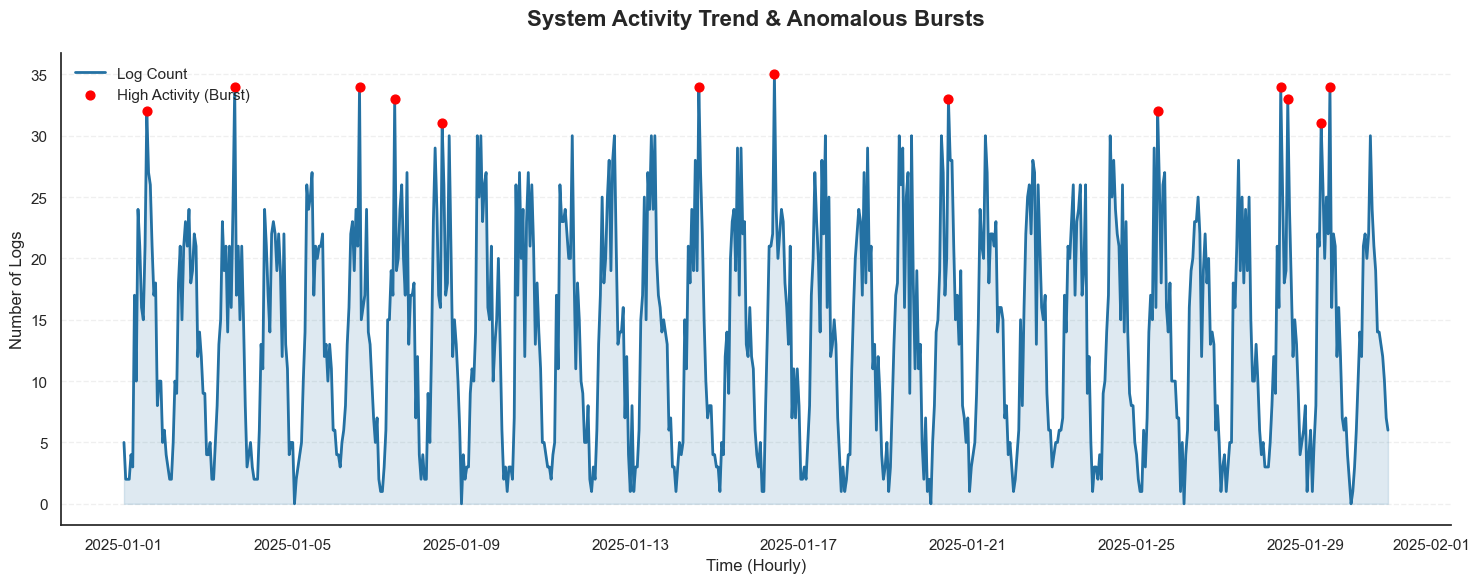

In [22]:
# 1. Hourly Resampling (using 'h' for compatibility with newer Pandas versions)
hourly_logs = df.resample('h', on='timestamp').size().reset_index(name='log_count')

# 2. Visualization Style
sns.set_theme(style="white") # Clean background
plt.figure(figsize=(15, 6))

# Main Line Chart with Area Fill
ax = sns.lineplot(data=hourly_logs, x='timestamp', y='log_count',
                  color='#2471a3', linewidth=2, label='Log Count')

plt.fill_between(hourly_logs['timestamp'], hourly_logs['log_count'],
                 color='#2471a3', alpha=0.15)

# 3. Highlight "Bursts" (e.g., log count > 30)
burst_threshold = 30
bursts = hourly_logs[hourly_logs['log_count'] > burst_threshold]
plt.scatter(bursts['timestamp'], bursts['log_count'], color='red', s=40,
            label='High Activity (Burst)', zorder=5)

# Chart Labels and Titles
plt.title('System Activity Trend & Anomalous Bursts', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Time (Hourly)', fontsize=12)
plt.ylabel('Number of Logs', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(frameon=False)

# Clean up layout
sns.despine()
plt.tight_layout()

plt.show()

### `Bar Chart` for event type distribution. To identify dominant event types.Which hosts generate the most logs?

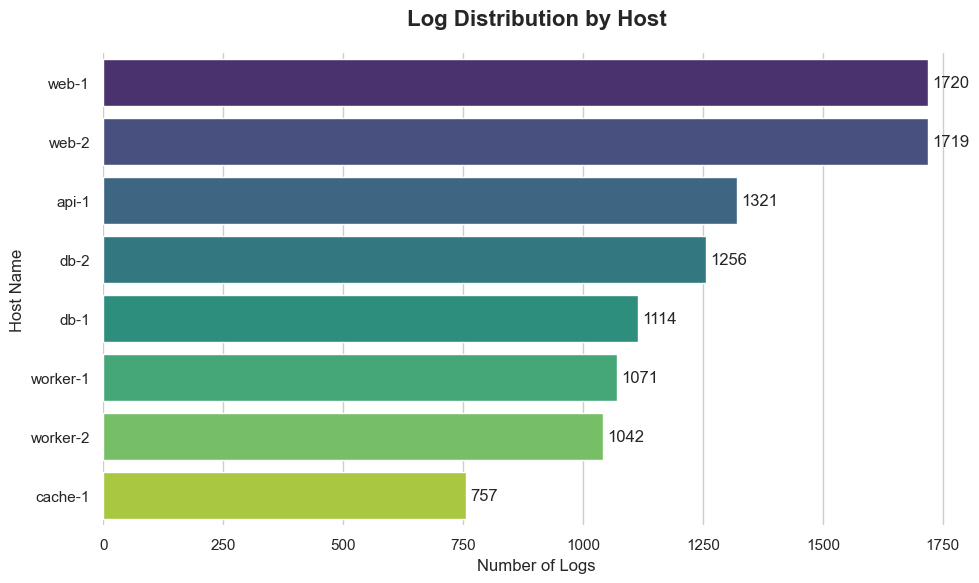

In [23]:
# 1. Count logs per host and sort them
# We use value_counts() to get the ranking automatically
host_counts = df['host'].value_counts().reset_index()
host_counts.columns = ['host', 'count']

# 2. Setup the visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create Horizontal Bar Chart
# Note: x is the count, y is the host for horizontal orientation
plot = sns.barplot(
    data=host_counts,
    x='count',
    y='host',
    hue='host', # Modern seaborn requires/prefers this for colors
    palette='viridis',
    legend=False
)

# 4. Add data labels to the end of each bar for quick reading
for i in plot.containers:
    plot.bar_label(i, padding=3)

# 5. Labels and Formatting
plt.title('Log Distribution by Host', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Number of Logs', fontsize=12)
plt.ylabel('Host Name', fontsize=12)

# Clean look
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


### `Bar-Chart` for severity distribution.

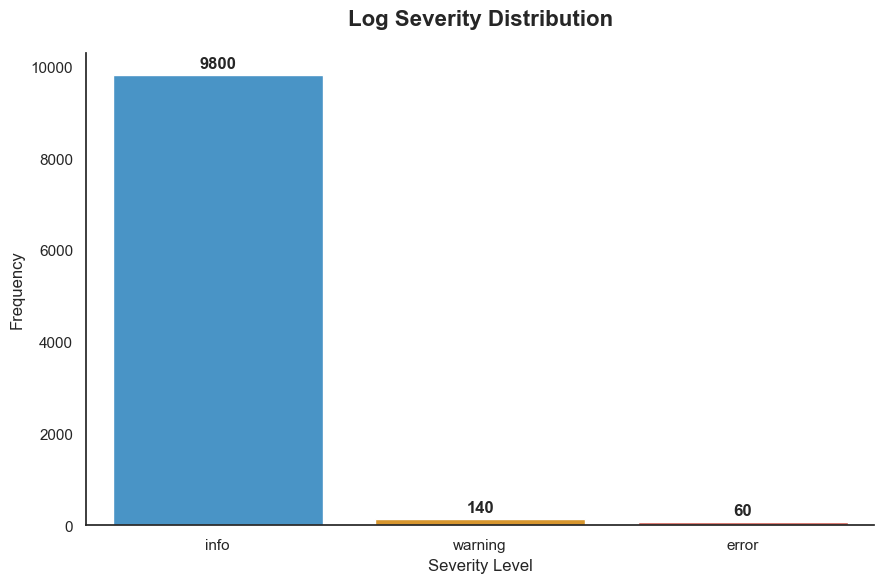

In [24]:
# 1. Count logs per severity level
# Assuming your column name is 'severity'
severity_counts = df['severity'].value_counts().reset_index()
severity_counts.columns = ['severity', 'count']

# 2. Define custom colors for better context (Blue for Info, Orange for Warning, Red for Error)
custom_palette = {
    "info": "#3498db",
    "warning": "#f39c12",
    "error": "#e74c3c"
}

# 3. Setup the visualization
sns.set_theme(style="white")
plt.figure(figsize=(9, 6))

# 4. Create the Bar Chart
plot = sns.barplot(
    data=severity_counts,
    x='severity',
    y='count',
    hue='severity',
    palette=custom_palette,
    legend=False
)

# 5. Add data labels on top of bars
for i in plot.containers:
    plot.bar_label(i, padding=3, fontweight='bold')

# 6. Labels and Formatting
plt.title('Log Severity Distribution', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Severity Level', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Clean look
sns.despine()
plt.tight_layout()
plt.show()

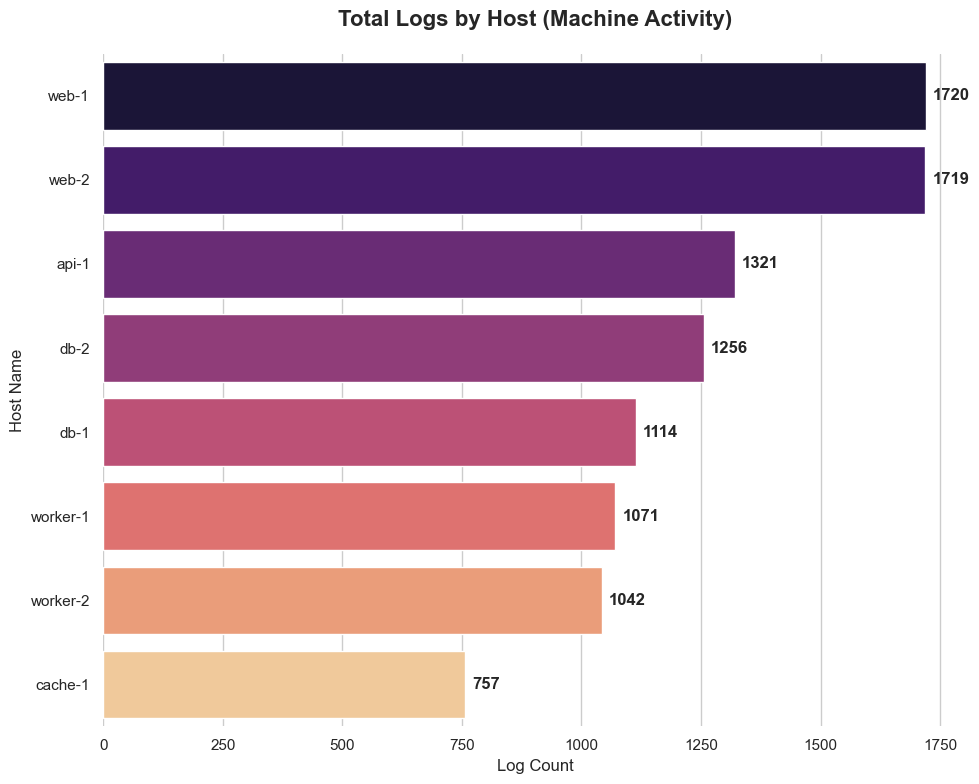

In [25]:
# 1. Count logs per host and sort them to show the busiest machines at the top
host_counts = df['host'].value_counts().reset_index()
host_counts.columns = ['host', 'log_count']

# 2. Setup the visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

# 3. Create Horizontal Bar Chart
# X = log_count (length of bar), Y = host (labels)
plot = sns.barplot(
    data=host_counts,
    x='log_count',
    y='host',
    hue='host',
    palette='magma',
    legend=False
)

# 4. Add data labels to the end of each bar for exact counts
for i in plot.containers:
    plot.bar_label(i, padding=5, fontweight='bold')

# 5. Professional Titles and Labels
plt.title('Total Logs by Host (Machine Activity)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Log Count', fontsize=12)
plt.ylabel('Host Name', fontsize=12)

# Clean up the visual
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()

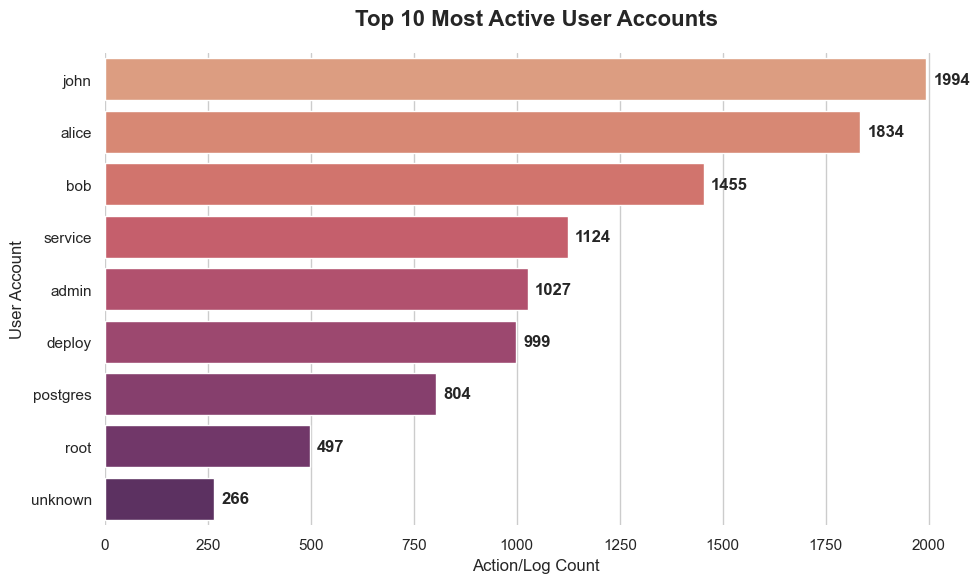

In [26]:
# 1. Count logs per user and take the top 10 for clarity
user_counts = df['user'].value_counts().head(10).reset_index()
user_counts.columns = ['user', 'activity_count']

# 2. Setup the visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create Horizontal Bar Chart
# Using a color palette that highlights activity intensity
plot = sns.barplot(
    data=user_counts,
    x='activity_count',
    y='user',
    hue='user',
    palette='flare',
    legend=False
)

# 4. Add activity counts as labels
for i in plot.containers:
    plot.bar_label(i, padding=5, fontweight='bold')

# 5. Professional Titles and Labels
plt.title('Top 10 Most Active User Accounts', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Action/Log Count', fontsize=12)
plt.ylabel('User Account', fontsize=12)

# Clean up layout
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()


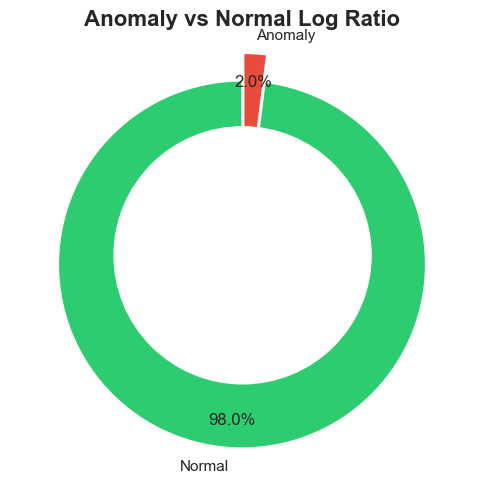

In [27]:
# 1. Prepare the data
# Assuming 'is_anomaly' column has 0 for Normal and 1 for Anomaly
counts = df['is_injected_anomaly'].value_counts()
labels = ['Normal', 'Anomaly']
sizes = [counts.get(0, 0), counts.get(1, 0)]
colors = ['#2ecc71', '#e74c3c'] # Green for Normal, Red for Anomaly

# 2. Create the Pie Chart
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=colors, pctdistance=0.85, explode=(0.05, 0.1))

# 3. Draw a white circle in the center to make it a Donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# 4. Labels and Formatting
plt.title('Anomaly vs Normal Log Ratio', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()

plt.show()


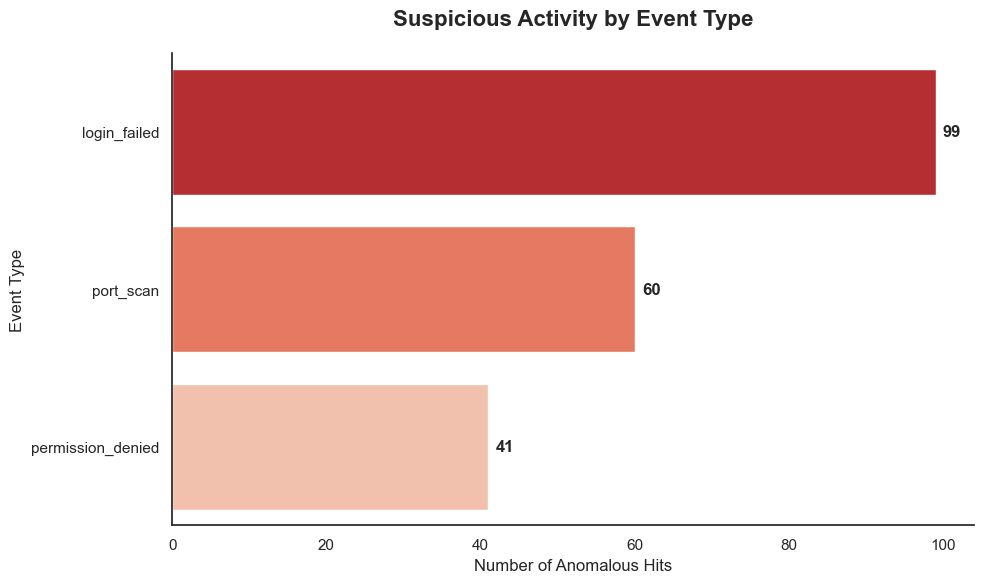

In [28]:
# 1. Filter for anomalies only (assuming 1 = Anomaly)
anomalies_df = df[df['is_injected_anomaly'] == 1]

# 2. Count types of anomalous events
anomaly_event_counts = anomalies_df['event_type'].value_counts().reset_index()
anomaly_event_counts.columns = ['event_type', 'count']

# 3. Setup the visualization
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# 4. Create Horizontal Bar Chart
# Using a "Reds" palette to signify suspicious/warning activity
plot = sns.barplot(
    data=anomaly_event_counts,
    x='count',
    y='event_type',
    hue='event_type',
    palette='Reds_r',
    legend=False
)

# 5. Add count labels
for i in plot.containers:
    plot.bar_label(i, padding=5, fontweight='bold')

# 6. Labels and Formatting
plt.title('Suspicious Activity by Event Type', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Number of Anomalous Hits', fontsize=12)
plt.ylabel('Event Type', fontsize=12)

# Clean look
sns.despine()
plt.tight_layout()

plt.show()


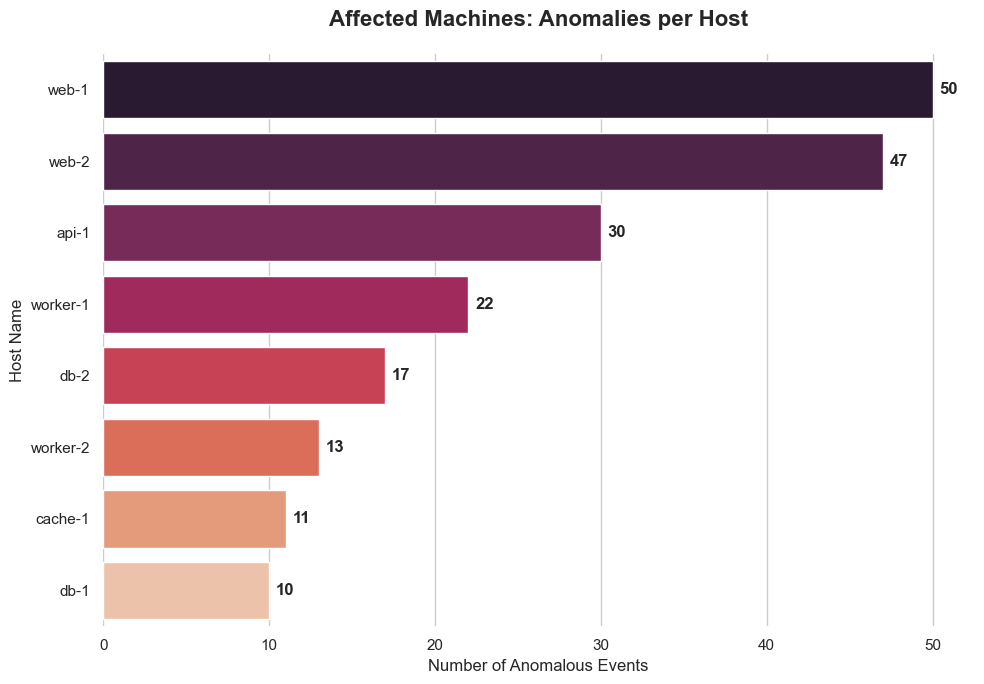

In [29]:
# 1. Filter for anomalies only (assuming 1 = Anomaly)
anomalies_only = df[df['is_injected_anomaly'] == 1]

# 2. Count anomalies per host
host_anomaly_counts = anomalies_only['host'].value_counts().reset_index()
host_anomaly_counts.columns = ['host', 'anomaly_count']

# 3. Setup the visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

# 4. Create Horizontal Bar Chart
# Using the 'rocket' palette to highlight "hot" zones of activity
plot = sns.barplot(
    data=host_anomaly_counts,
    x='anomaly_count',
    y='host',
    hue='host',
    palette='rocket',
    legend=False
)

# 5. Add count labels for precision
for i in plot.containers:
    plot.bar_label(i, padding=5, fontweight='bold')

# 6. Professional Titles and Labels
plt.title('Affected Machines: Anomalies per Host', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Number of Anomalous Events', fontsize=12)
plt.ylabel('Host Name', fontsize=12)

# Clean look
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()


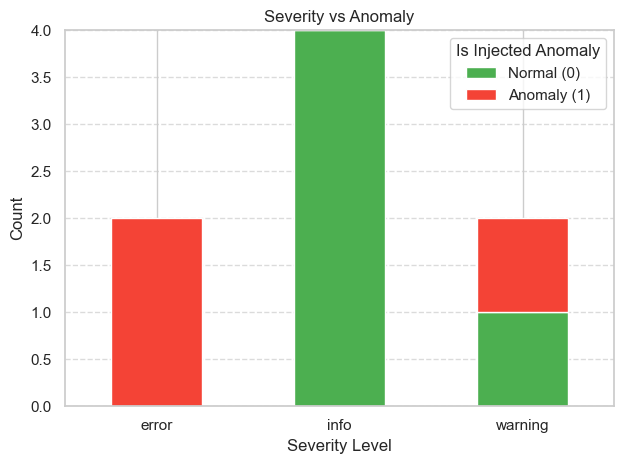

In [32]:
# 1. Provide mock data sample
# Note: If you use your real dataframe (df), you can delete this section.
data = {
    "severity": [
        "info",
        "info",
        "info",
        "warning",
        "warning",
        "error",
        "error",
        "info",
    ],
    "is_injected_anomaly": [0, 0, 0, 1, 0, 1, 1, 0],
}
df = pd.DataFrame(data)

# 2. Create cross-tabulation of Severity and Anomaly columns
cross_tab = pd.crosstab(df["severity"], df["is_injected_anomaly"])

# 3. Visualize the Stacked Bar Chart
ax = cross_tab.plot(kind="bar", stacked=True, color=["#4caf50", "#f44336"])

# Visual adjustments for the chart
plt.title("Severity vs Anomaly")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.xticks(rotation=0)  # For keeping X-axis labels horizontal
plt.legend(["Normal (0)", "Anomaly (1)"], title="Is Injected Anomaly")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Display the chart on screen
plt.tight_layout()
plt.show()


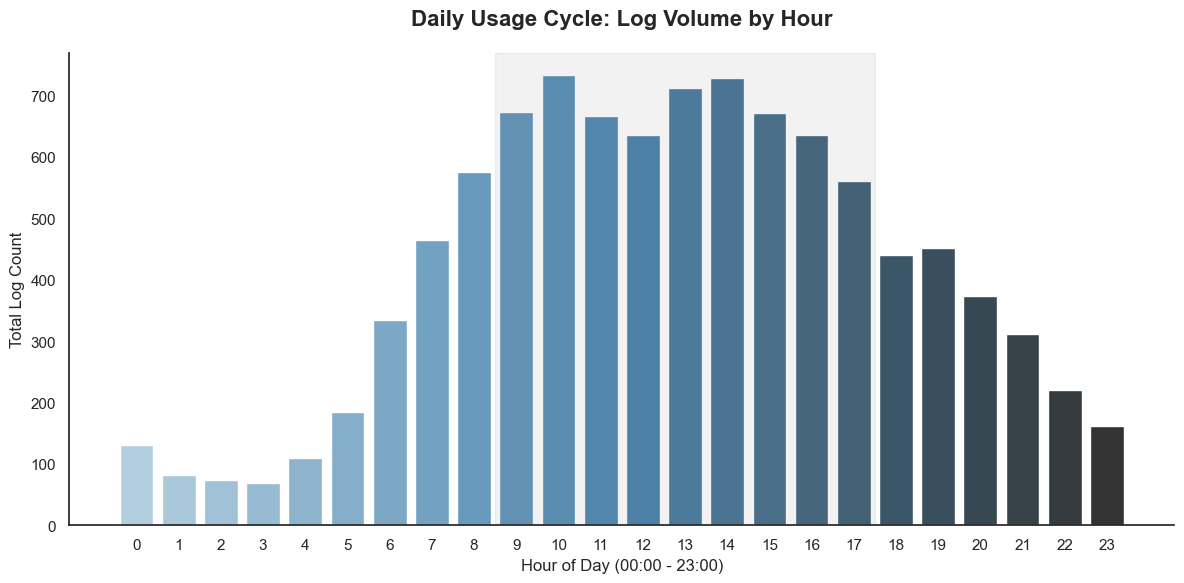

In [55]:
# 1. Extract the hour from the timestamp
# This creates a new column with values from 0 to 23
df['hour'] = df['timestamp'].dt.hour

# 2. Count logs per hour
hourly_dist = df['hour'].value_counts().sort_index().reset_index()
hourly_dist.columns = ['hour', 'log_count']

# 3. Setup the visualization style
sns.set_theme(style="white")
plt.figure(figsize=(12, 6))

# 4. Create the Bar Chart
# Using a 'coolwarm' or 'Blues' palette to show the intensity of time
plot = sns.barplot(
    data=hourly_dist,
    x='hour',
    y='log_count',
    hue='hour',
    palette='Blues_d',
    legend=False
)

# 5. Professional Titles and Labels
plt.title('Daily Usage Cycle: Log Volume by Hour', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Hour of Day (00:00 - 23:00)', fontsize=12)
plt.ylabel('Total Log Count', fontsize=12)

# Optional: Add a vertical line to separate business hours (e.g., 9 to 18)
plt.axvspan(8.5, 17.5, color='gray', alpha=0.1, label='Business Hours')

# Clean look
sns.despine()
plt.tight_layout()

plt.show()


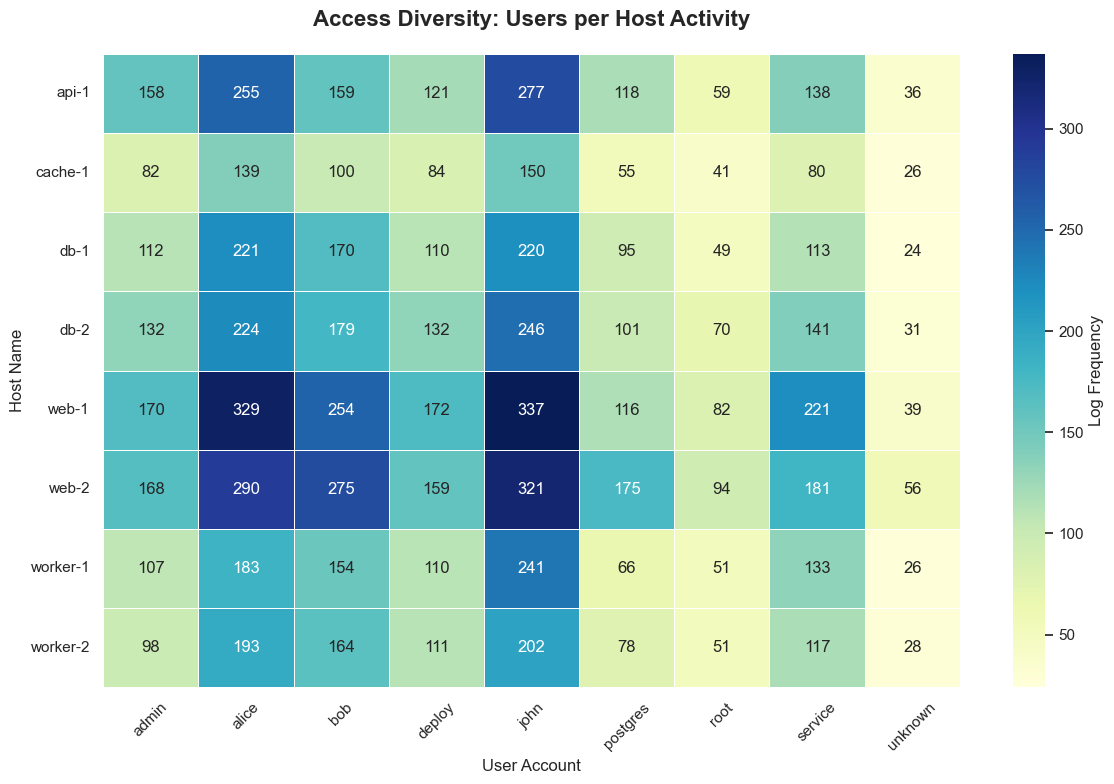

In [54]:
# 1. Create a Cross-tabulation (Matrix) of Hosts and Users
# We count the number of log entries for each user on each host
user_host_matrix = pd.crosstab(df['host'], df['user'])

# 2. Setup the visualization
plt.figure(figsize=(12, 8))

# 3. Create the Heatmap
# 'cmap' sets the color intensity (YlGnBu is professional and readable)
# 'annot=True' displays the actual numbers in the cells
sns.heatmap(user_host_matrix,
            annot=True,
            fmt='d',
            cmap='YlGnBu',
            linewidths=.5,
            cbar_kws={'label': 'Log Frequency'})

# 4. Labels and Formatting
plt.title('Access Diversity: Users per Host Activity', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('User Account', fontsize=12)
plt.ylabel('Host Name', fontsize=12)

# Rotate labels if you have many users to prevent overlap
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


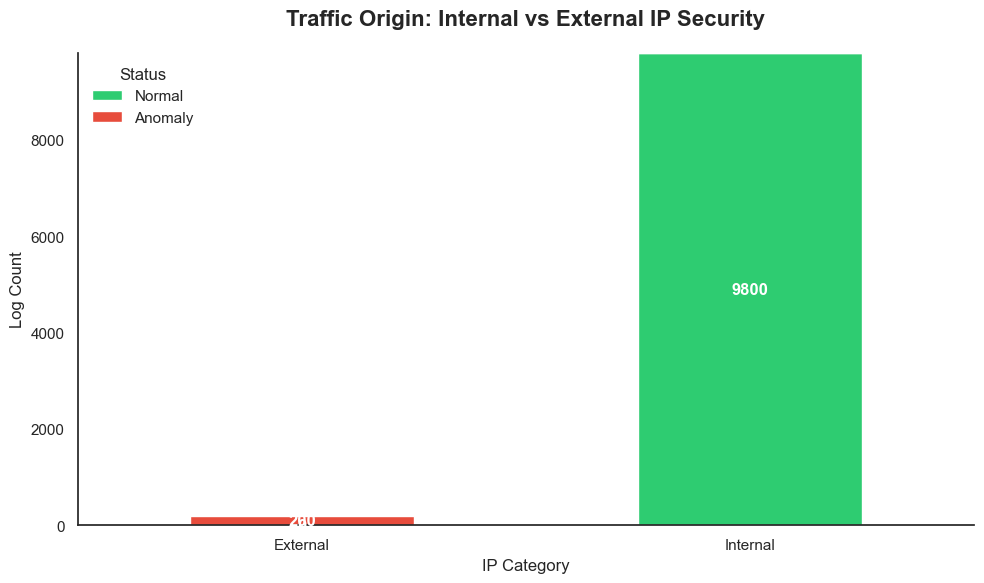

In [53]:
# 1. Categorize IPs
# Logic: If it starts with '192.168.', it's Internal; otherwise, External
df['ip_category'] = df['ip_address'].apply(lambda x: 'Internal' if str(x).startswith('192.168.') else 'External')

# 2. Create a summary for the Stacked Bar Chart
# This shows how many Normal vs Anomaly logs exist for each IP category
ip_summary = df.groupby(['ip_category', 'is_injected_anomaly']).size().unstack(fill_value=0)
ip_summary.columns = ['Normal', 'Anomaly']

# 3. Setup the visualization
plt.figure(figsize=(10, 6))

# 4. Create the Stacked Bar Chart
ip_summary.plot(kind='bar', stacked=True,
                color=['#2ecc71', '#e74c3c'], # Green for Normal, Red for Anomaly
                ax=plt.gca())

# 5. Add data labels
for c in plt.gca().containers:
    plt.gca().bar_label(c, label_type='center', fontweight='bold', color='white')

# 6. Labels and Formatting
plt.title('Traffic Origin: Internal vs External IP Security', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('IP Category', fontsize=12)
plt.ylabel('Log Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status', frameon=False)

# Clean look
sns.despine()
plt.tight_layout()
plt.show()
